In [1]:
from math import comb, log, ceil

from typing import List, Optional, Tuple

import random

In [2]:
from pricing import (
    risk_neutral_p, barrier_level, vanilla_call,
    knockout_call_brute, knockout_call_reflection,
    monte_carlo_ko, verify, sample_blocked_path, reflect_path,
)

from visualization import draw_binomial_tree, draw_reflection

## 0. Introduction
In this notebook, we create an option pricer for single barrier options (up-and-out calls). It should be quite self-contained, only requiring a basic understanding of combinations and lattice paths.

We will use the canonical binomial option pricing model (Cox-Ross-Rubinstein) and then extend it to a single-barrier option call by counting only safe paths (paths below the knock-out barrier) using the reflection principle from combinatorics. 

We will also include a comparison of this model with brute-force, closed-form, and Monte Carlo methods. Note that unlike the other methods in this notebook, the Monte Carlo pricing model will not be derived from scratch. 

## 1. A single barrier call option

A **European call option** gives its holder the right, not the obligation, to buy one
share at a fixed **strike** $K$ at **expiry** $T$. Exercising only when it pays gives the
payoff:

$$\text{payoff}(S_T) = \max(S_T - K,\; 0).$$

A **single barrier option** adds one rule. The **up-and-out call** has a barrier $H$; if the
stock ever reaches $H$ during the contract's life it is knocked out. That is, it dies and pays
zero forever:

$$\text{payoff}_{KO} =
\begin{cases}
0 & \text{if } S_t \ge H \text{ for some } t \in [0,T]\\[4pt]
\max(S_T - K,\,0) & \text{otherwise}
\end{cases}$$

The vanilla payoff depends only on the final price $S_T$. However, the single barrier option depends on its entire lifetime (if it ever crosses $H$, it is worth 0. Otherwise, it is priced like a vanilla option. Hence we need a way to model its entire path.

## 2. Pricing a call option

To price a call option fairly (no expected gain or loss to either party), a naive approach would be to take the expected payoff given some forecasted probabilities. However, an obvious downside is that we cannot predict the future. The subtler and bigger one is that different people value the same risky payoff differently depending on their tolerance for volatility, so an average under "real" probabilities is not a price anyone is forced to agree on. What we want instead is a risk neutral measure; a single set of probabilities under which the price is pinned down by no arbitrage, so everyone agrees regardless of their personal view of the stock.

**Suppose** A stock trades at 100 today. For simplicity assume it can only move
to 110 (up) or 90 (down) tomorrow. Consider a call with strike 100. Its payoff
tomorrow is 10 in the up state ($110 - 100$) and 0 in the down state (90 is
below the strike).

**Replication step:** Instead of guessing probabilities, build a portfolio of
$\Delta$ shares and $B$ in cash that reproduces the option's payoff in both
states:

$$
\begin{aligned}
110\,\Delta + B &= 10 \quad \text{(up state)} \\
 90\,\Delta + B &= 0  \quad \text{(down state)}
\end{aligned}
$$

Solving this system, we get $\Delta = 0.5$, $B = -45$. The cost of assembling this portfolio today is

$$
100\,\Delta + B = 100(0.5) - 45 = 5.
$$

Since the portfolio pays exactly what the option pays in every state, the
option must cost 5 today. Any other price lets someone make riskless profit by buying the option (portfolio) and selling the portfolio (option) for more expensive. This is an arbitrage; we assume these don't happen in theory, since any arbitrage opportunity is considered instantly taken care of. 

**Risk neutral probabilities:** We can repackage that same answer as an
expectation. Find probabilities $p$ (up) and $1 - p$ (down) under which the
stock's expected value equals its current price (interest rate zero):

$$
110\,p + 90\,(1 - p) = 100 \implies 20p = 10 \implies p = 0.5.
$$

Pricing the option as an expectation under these probabilities gives:

$$
\text{price} = \mathbb{E}_{\text{risk-neutral}}[\,\text{payoff}\,]
            = 0.5(10) + 0.5(0) = 5
$$

This is the same 5 we got from replication. Notice the real world forecasted probability of an up
move isn't used. That rids us of our first problem about price prediction. 

## 3 · Binomial model

Now we can move on to bare bones of the model.

We first Split $[0,T]$ into $N$ equal steps. At each step the stock is multiplied by one
of two factors: $u$ if it moves up, or $d = 1/u$ if it moves down, with
$d < 1 < u$. Each step is independent of the others.

Notice that with the choice of $u$ and $d$, an up move then down move will return us to the original price. This makes the tree recombining, which helps us reach an $O(n)$ runtime (as will be explained).
$$S_0 \cdot u \cdot d = S_0 \cdot u \cdot \tfrac{1}{u} = S_0.$$
Because ups and downs cancel in pairs, the *order* of the moves is irrelevant to
the final price. A path with $k$ up-moves and $N - k$ down-moves therefore ends at:
$$S_N = S_0\, u^{k}\, d^{\,N-k} = S_0\, u^{k}\, u^{-(N-k)} = S_0\, u^{\,2k - N}.$$
This collapses the $2^N$ distinct move-sequences down to only $N + 1$ possible
terminal prices, indexed by $k = 0, 1, \dots, N$.

After $t$ steps, let $k_t$ be the number of ups so far and define the *displacement*
$$x_t \;=\; (\text{ups}) - (\text{downs}) \;=\; k_t - (t - k_t) \;=\; 2k_t - t.$$
This quantity moves by $\pm 1$ at every step. On an up-move both
$k_t$ and $t$ rise by one, so $x_t \to x_t + 1$; on a down-move only $t$ rises,
so $x_t \to x_t - 1$. The displacement is therefore a simple random walk on the
integer lattice, starting at $x_0 = 0$.

At the final step $t = N$, the running displacement equals the terminal displacement,
$$x_N \;=\; 2k_N - N \;=\; 2k - N,$$ and the terminal price is $S_N = S_0\, u^{\,x_N}$. The terminal value $2k - N$
ranges over $-N, -N+2, \dots, N-2, N$ in steps of two as $k$ runs from $0$ to
$N$ (it shares the parity of $N$), whereas the running displacement that
produces it steps in $\pm 1$ increments along the way. We can now see that the final price is simply the endpoint, but whether or not the option is 'knocked out' depends on its path.

Here's a drawing of what we have so far from `visualization.py`:

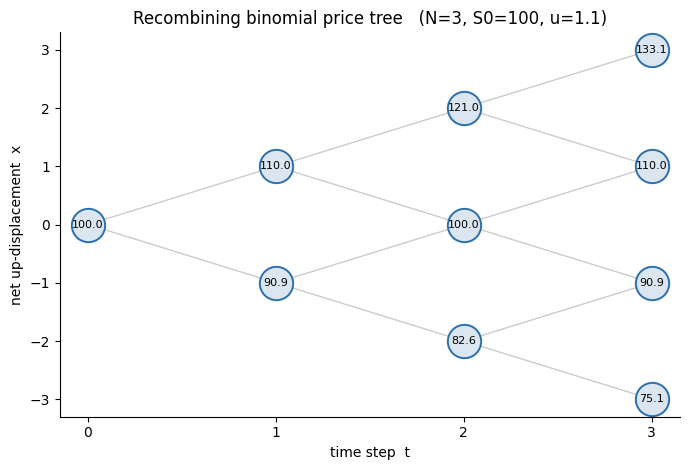

In [3]:
draw_binomial_tree()

## 4. The risk-neutral probability for the binomial model

In 2., we found the risk neutral probability for a very simple example where the stock
moved to 110 or 90. The binomial model of 3. uses *multiplicative* moves with
$d = 1/u$ instead, so we redo the same step in this setting to get
the probability the rest of the notebook will use.

The risk neutral probability is the one under which the stock's expected price
one step ahead equals its current price (with interest rate zero):
$$\mathbb{E}[\,S_{t+1} \mid S_t\,] = S_t.$$

Writing out the expectation over an up-move (factor $u$, probability $p$) and a
down-move (factor $1/u$, probability $1 - p$):
$$p\, u\, S_t + (1 - p)\, \tfrac{1}{u}\, S_t = S_t.$$

So the up-probability is
$$p = \frac{1}{u + 1}.$$

## 5. Pricing the vanilla call

We now have every piece needed to price a vanilla call. 
$$V_{\text{vanilla}} = \mathbb{E}\big[\max(S_N - K,\, 0)\big],$$
where the expectation runs over all $2^N$ paths.

Recall from (3) that every path with the same up-count $k$ shares the same
terminal price $S_0 u^{2k-N}$, and therefore the same payoff. Each such path
also has the same probability $p^k (1-p)^{N-k}$ (it has $k$ ups and $N - k$
downs, in some order). So instead of summing over paths, we sum over the
$N + 1$ possible values of $k$, weighting each by the number of paths that
achieve it. That count is exactly the number of ways to choose which $k$ of the
$N$ steps are ups:
$$\#\{\text{paths with } k \text{ ups}\} = \binom{N}{k}.$$

Putting it all together:
$$
V_{\text{vanilla}} = \sum_{k=0}^{N}
\binom{N}{k}\, p^{k}\,(1-p)^{N-k}\,
\max\!\big(S_0\, u^{\,2k-N} - K,\; 0\big).
$$
This is the **Cox-Ross-Rubinstein formula**. Since it has only
$N + 1$ terms, it evaluates in $O(N)$ instead of $O(2^N)$.

## 6. Adjusting the pricer for single barrier options

For the vanilla call, we grouped paths by their up-count $k$, because every path
with the same $k$ had the same payoff. Now suppose we consider a single barrier option. Two paths can
have the same $k$ and reach the same endpoint, but one might rise early, touch $H$, and die,
while the other dips first and only climbs later, surviving to expiry.

So $\binom{N}{k}$ is now the wrong weight. It counts *all* paths to a given
endpoint, including the ones the barrier kills. What we need instead is a finer
count: among the $\binom{N}{k}$ paths ending at displacement $x = 2k - N$, how
many of them *never reach the barrier level $B$*? Call this $N_{\text{safe}}(x)$.

If we had that count, the barrier price would be the vanilla formula with
$\binom{N}{k}$ swapped out for $N_{\text{safe}}(x)$:
$$
V_{KO} = \sum_{\substack{k=0 \\ x = 2k-N}}^{N}
N_{\text{safe}}(x)\; p^{k}(1-p)^{N-k}\;
\max\!\big(S_0 u^{x} - K,\; 0\big).
$$
Endpoints at or above the barrier ($x \ge B$) contribute nothing, since any path
reaching them has already been knocked out. 

To find these 'good' paths that don't die out, we will use the reflection principle

## 7. The reflection principle

We need to count paths from $0$ to $x$ (with $x < B$) that never reach level
$B$. It is easier to count the *complement* (the paths that *do* reach $B$) and
subtract.

**Theorem (Reflection Principle).** Let $B$ be a positive integer, and consider
$N$-step $\pm 1$ paths starting at $0$ and ending at $x$, with $x < B$. The
number of such paths that touch level $B$ at some point equals the *total*
number of $N$-step paths from $0$ to $2B - x$ (with no constraint at all):
$$
\#\{\text{paths } 0 \to x \text{ that touch } B\}
= \binom{N}{\,(N + 2B - x)/2\,}.
$$

**Proof (a bijection).** Take any path from $0$ to $x$ that touches $B$. Let
$d$ be its *first hitting time*, the earliest step at which it reaches $B$.
Leave the path untouched up to $d$, and reflect every step after $d$ about
the horizontal line $y = B$, flipping each $+1$ into a $-1$ and vice versa.

The part before $d$ is unchanged and still ends at height $B$. The part after
$d$ originally travelled from $B$ down to $x$, a net drop of $B - x$;
reflected, that same tail now travels from $B$ up by $B - x$, landing at
$B + (B - x) = 2B - x$. So the reflected path ends at $2B - x$.

This map is invertible. Take any path from $0$ to $2B - x$. Since
$2B - x > B$ (because $x < B$), such a path must cross $B$ to reach its
endpoint, so it has a first hitting time too. Reflect its tail after that first
hit and you recover a path from $0$ to $x$ that touches $B$. The two operations
undo each other, so they form a bijection, and the two sets have equal size.
Since the right-hand set is unconstrained, its size is just the total number of
paths to $2B - x$, namely $\binom{N}{(N + 2B - x)/2}$. $\blacksquare$

Hence the good paths:
$$
N_{\text{safe}}(x)
= \underbrace{\binom{N}{(N+x)/2}}_{\text{all paths to } x}
\;-\;
\underbrace{\binom{N}{(N+2B-x)/2}}_{\text{paths to } x \text{ that touch } B}.
$$

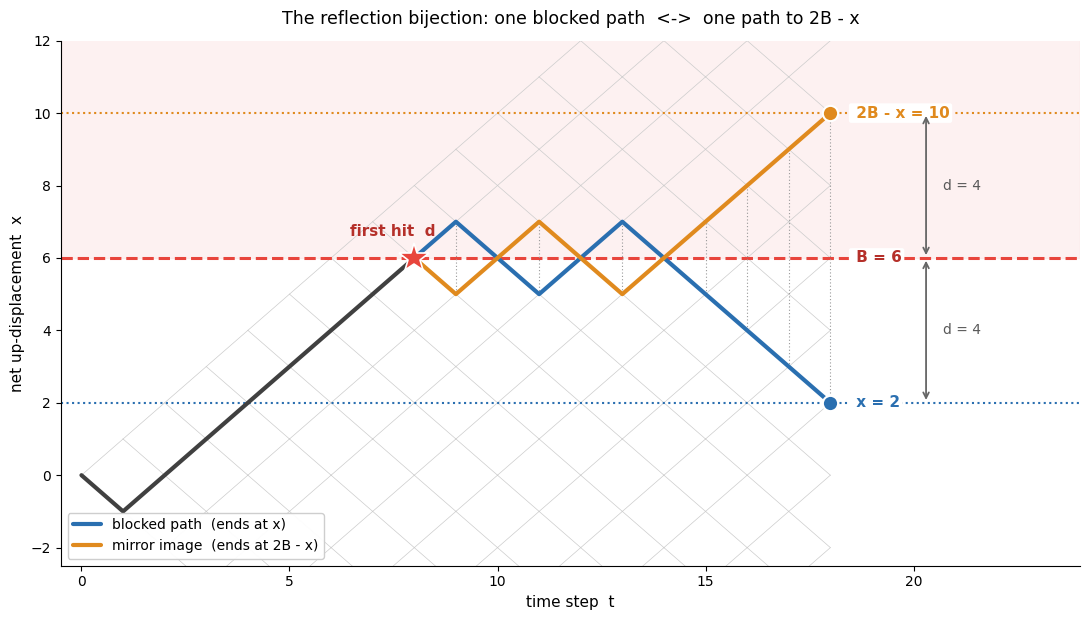

In [4]:
# Render the reflection bijection: a blocked path and its mirror image
N, B, x_end = 18, 6, 2
draw_reflection(N, x_end, B, seed=3)

# Numeric check: the blocked path ends at x, its mirror ends at 2B - x
moves = sample_blocked_path(N, x_end, B, seed=3)
reflected, hit = reflect_path(moves, B)

## 8. The closed-form barrier pricer

For readability, note that the contract states a knock-out price $H$ in
dollars, but the walk lives on integer lattice levels. We convert $H$ into the
smallest lattice level $B$ whose price is at or above $H$. Since the price at
level $B$ is $S_0 u^B$, we want the smallest integer $B$ with $S_0 u^B \ge H$, which is:
$$B = \left\lceil \frac{\log(H / S_0)}{\log u} \right\rceil.$$

We also note that when the barrier is far away, the reflected
endpoint $2B - x$ can exceed $N$, the highest level reachable in $N$ steps. Then
$\binom{N}{(N+2B-x)/2}$ is read as zero, which is exactly right: if the walk
cannot even reach that high, no path to $x$ touches $B$, so there are zero bad
paths and every path to $x$ is safe. Python's `math.comb` returns $0$ for
$k > N$ automatically, so this case needs no special handling beyond guarding
against negative arguments.

Now we can plug everything in:
$$
V_{KO} = \sum_{\substack{k=0 \\ x = 2k-N \\ x < B}}^{N}
\left[\binom{N}{k} - \binom{N}{(N+2B-x)/2}\right]
p^{k}(1-p)^{N-k}\,\max\!\big(S_0 u^{x} - K,\; 0\big).
$$
This is the entire closed-form single barrier option pricer. Again, this runs in $O(n)$.

Now we check this against a brute force enumeration for N=20 as well as 100-K path Monte Carlo. This is merely to test similarity of our model's pricing to widely accepted pricing methods (BOPM, Monte Carlo)

In [5]:
verify()

  u      K    H      brute       refl      |diff|    MC mean       95% CI              result
---------------------------------------------------------------------------------------------
   1.1   100   130    0.747332    0.747332   1.61e-14    0.747600  [0.7235, 0.7717]    PASS
  1.08    95   140    4.829982    4.829982   2.82e-13    4.859053  [4.7973, 4.9208]    PASS
  1.05   100   120    0.836972    0.836972   1.03e-12    0.830762  [0.8134, 0.8481]    PASS


### Done!